# Linear Regression

Linear regression models are:
- a good starting point for regression tasks
- easy and quick to fit
- very interpretable.


Let us start with linear regression model and then generalize it to models to account for more complicated paterns in data.


In [1]:
# Our standard boiler plate imports
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

## Simple Linear Regression (Ordinary Least Squares)

It is a linear model of the following simple form
$$
y = b+ ax
$$
where $b$ and $a$ are the *intercept* and *slope* of the linear line. Let us see how we can build a linear regression model in scikit-learn:

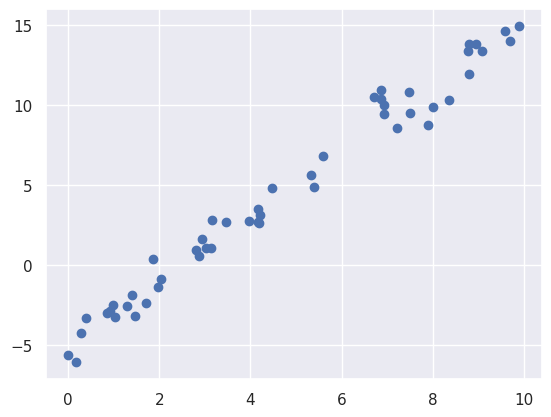

In [2]:
# Let us generate some random data scattered around a linear line with a slope of 2 and intecept of -5:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50) # produces uniformly distributed random numbers between 0 and 1
y = 2 * x - 5 + rng.randn(50) # produces standard normal random variables with mean 0 and standard dev 1
plt.scatter(x, y);

In [3]:
x.shape

(50,)

In [4]:
x = x[:,np.newaxis]
x.shape

(50, 1)

We can use Scikit-Learn's ``LinearRegression`` estimator to fit this data and construct the best-fit line:

In [5]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)

model.fit(x, y)


LinearRegression()

The slope and intercept of the data are contained in the model's fit parameters, which in Scikit-Learn are always marked by a trailing underscore.
Here the relevant parameters are ``coef_`` and ``intercept_``:

In [6]:
print("Model slope:    ", model.coef_[0])
print("Model intercept:", model.intercept_)
print("R^2 value:", model.score(x,y)) # the overall quality of the linear regression model
# a number between 0 and 1, the closer it is to 1, the better the overall quality of the model is.

Model slope:     2.0272088103606953
Model intercept: -4.998577085553204
R^2 value: 0.9790800609430612


We note that these estimations are very close to the input values.

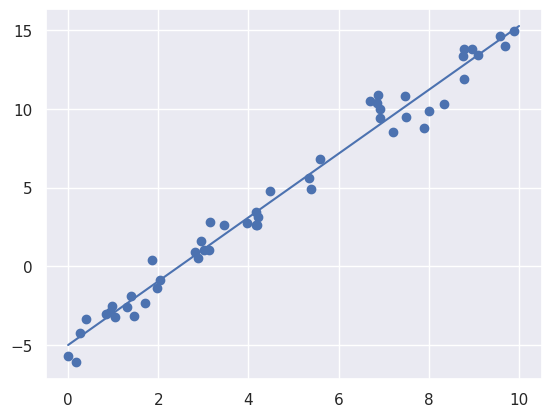

In [7]:
# Let us create some predictions using .predict function for some x values.
xfit = np.linspace(0, 10, 1000)
yfit = model.predict(xfit[:, np.newaxis])

# let us plot the linear regression line along with scatter plot of the training data
plt.scatter(x, y)
plt.plot(xfit, yfit);

The ``LinearRegression`` estimator in scikit-learn can also handle multidimensional linear models of the following form
$$
y = a_0 + a_1 x_1 + a_2 x_2 + \cdots
$$
where there are multiple predictors. However, the multidimensional nature of such regressions makes them more difficult to visualize. Let us build a linear regression model with three predictors as follows:

In [ ]:
rng = np.random.RandomState(1)
X = 10 * rng.rand(100, 3)
y = 0.5 + np.dot(X, [1.5, -2., 1.])

model.fit(X, y)
print(model.intercept_)
print(model.coef_)
print(model.score(X,y))

0.5000000000000033
[ 1.5 -2.   1. ]
1.0


## Basis Function Regression

We can adapt linear regression to account for nonlinear relationships between variables by transforming the data according to *basis functions*.``PolynomialRegression`` is an example of such technique:
$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots
$$
Notice that this is *still a linear model*.  In other words, one-dimensional $x$ values are projected into a higher dimension, so that a linear fit can fit more complicated relationships between $x$ and $y$.

### Polynomial basis functions

Im Scikit-Learn, we can do polynomial projections using the ``PolynomialFeatures`` transformer:

In [8]:
from sklearn.preprocessing import PolynomialFeatures
x = np.array([2, 3, 4])
poly = PolynomialFeatures(3, include_bias=False)
poly.fit_transform(x[:, None])

array([[ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

The transformer has converted our one-dimensional array into a three-dimensional array by taking the exponent of each value.
This new, higher-dimensional data representation can then be plugged into a linear regression to obtain polynomial regression.

The easiest way to do this is to use a pipeline. Let us make a 10th degree polynomial model as follows:

In [17]:
from sklearn.pipeline import make_pipeline
poly_model = make_pipeline(PolynomialFeatures(5),
                           LinearRegression())

With this transformation, we can use the linear model to fit much more complicated relationships between $x$ and $y$. For example, here is a sine wave with noise:

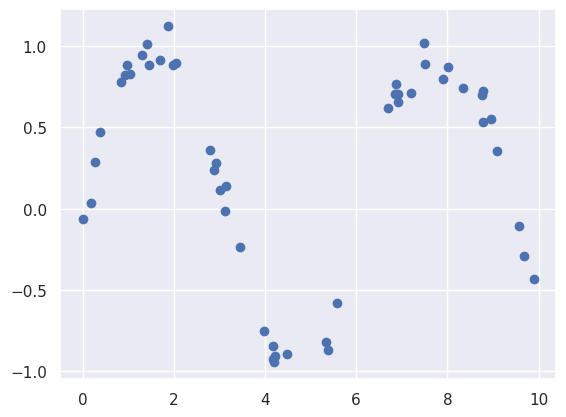

In [9]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)
plt.scatter(x, y)

In [18]:
poly_model.fit(x[:, np.newaxis], y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=5)),
                ('linearregression', LinearRegression())])

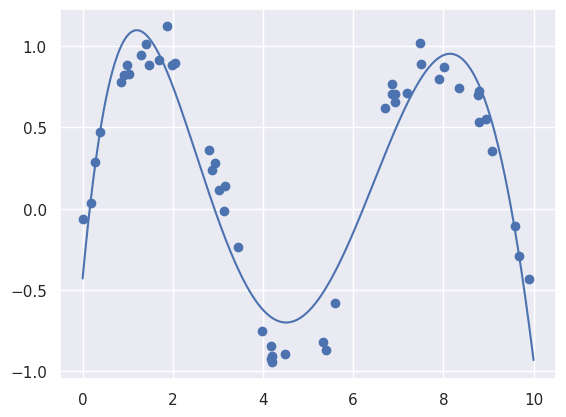

In [19]:
xfit = np.linspace(0, 10, 1000)
yfit = poly_model.predict(xfit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(xfit, yfit);

## Regularization

The introduction of basis functions into our linear regression makes the model much more flexible, but it also can very quickly lead to over-fitting. We can deal with overfitting by penalizing large values of model parameters. Such a penalty aproach is called **Regularization**. It has two important forms:

### Ridge regression ($L_2$ Regularization)

Ridge regression penalizes the sum of squares of the model coefficients. The penalty on the model fit would be
$$
P = \alpha\sum_{n=1}^N \theta_n^2
$$
where $\alpha$ is the complexity parameter that controls the strength of the penalty (the amount of shrinkage): the larger the value of $\alpha$, the greater the amount of shrinkage and thus the coefficients become more robust to overfitting and collinearity. The higher $\alpha$ means, the more regularization and the simpler models. We can use ``Ridge`` estimator in Scikit-Learn to form a Ridge regression model.

In [ ]:
from sklearn import linear_model
reg = linear_model.Ridge(alpha=.2)
X = [[0, 0], [0, 0], [1, 1]]
y = [0, .1, 1]
reg.fit(X,y)
print("Ridge regression coefficients", reg.coef_)
print("Ridge regression intercept", reg.intercept_)

Ridge regression coefficients [0.41304348 0.41304348]
Ridge regression intercept 0.09130434782608698


In [ ]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
X = [[0, 0], [0, 0], [1, 1]]
y = [0, .1, 1]
reg.fit(X,y)
print("Linear regression coefficients",reg.coef_)
print("Linear regression intercept", reg.intercept_)

Linear regression coefficients [0.475 0.475]
Linear regression intercept 0.050000000000000155


**Controlling model complexity**:  
- When $\alpha \to 0$, we obtain the standard linear regression model.
- When $\alpha \to \infty$, all regression coefficients will be completely shrinked to zero.


### Lasso regression ($L_1$ regularization)

Lasso regression penalizes the sum of absolute values of regression coefficients:
$$
P = \alpha\sum_{n=1}^N |\theta_n|
$$

When using the lasso, some regression coefficients become EXACTLY zero! That is, some features in the model are entirely IGNORED by the model. This can be viewed as a form of AUTOMATIC FEATURE SELECTION. Furthermore, Lasso  
- makes a model easier to interpret
- can reveal the most important features of your model

Though this is conceptually very similar to ridge regression, the results can differ surprisingly: for example, due to geometric reasons lasso regression tends to favor *sparse models* where possible: that is, it preferentially sets model coefficients to exactly zero.

We can see this behavior in duplicating the ridge regression figure, but using L1-normalized coefficients:

In [ ]:
from sklearn import linear_model
reg = linear_model.Lasso(alpha=.2)
X = [[0, 0], [0, 0], [1, 1]]
y = [0, .1, 1]
reg.fit(X,y)
print("Lasso regression coefficients", reg.coef_)
print("Lasso regression intercept", reg.intercept_)

Lasso regression coefficients [0.05 0.  ]
Lasso regression intercept 0.35000000000000003


We note that the optimal value for the model complexity parameter $\alpha$ should be determined by cross-validation.

## Practice: Boston Housing Dataset

Linear models are powerful tools when we analyze a high-dimensional data (data sets with many number of features). However, there is also a higher chance of overfitting. Let us look at Boston Housing data set: 506 samples and 104 features.

In [20]:
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.3 MB/s eta 0:00:00


In [21]:
import numpy as np

In [22]:

X, y = mglearn.datasets.load_extended_boston()
print(X.shape)

(506, 104)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

lr = LinearRegression().fit(X_train, y_train)

print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))
print("Number of features used under linear regression:", np.sum(lr.coef_ !=0))


Training set score: 0.95
Test set score: 0.61
Number of features used under linear regression: 104


The performance (R-square value) on the test set is much lower than that on the training set. This difference is a sign of overfitting. Let us find a model that allows us to control model complexity (i.e., regularization = restricting a model to avoid overfitting). Let us begin with a Ridge regression (L2 reqularization).

In [29]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 0.8).fit(X_train, y_train)
print("Training set score under Ridge regression: {:.2f}".format(ridge.score(X_train,y_train)))
print("Test set score under Ridge regression: {:.2f}".format(ridge.score(X_test,y_test)))
print("Number of features used under Ridge regression:", np.sum(ridge.coef_ !=0))

Training set score under Ridge regression: 0.89
Test set score under Ridge regression: 0.76
Number of features used under Ridge regression: 104


Our performance improved on the test data with a regularized regression model - Ridge regression. Our model is simpler than before (thus, the training set score gets lower), however, our model has a better generalization than the linear regression model. Let us check how Lasso regression would perform on this data set as an alternative regularization model.

In [38]:
from sklearn import linear_model

lasso = linear_model.Lasso(alpha=0.015).fit(X_train, y_train)
print("Training set score under Lasso regression: {:.2f}".format(lasso.score(X_train,y_train)))
print("Test set score under Lasso regression: {:.2f}".format(lasso.score(X_test,y_test)))
print("Number of features used under Lasso regression:", np.sum(lasso.coef_ !=0))

Training set score under Lasso regression: 0.88
Test set score under Lasso regression: 0.75
Number of features used under Lasso regression: 28


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.413e+00, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(


In [39]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split

# Example Data (replace with your actual data)
# If X is a DataFrame:
# X = pd.DataFrame(...)
# y = pd.Series(...)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# If X is a NumPy array:
# X = np.array(...)
# y = np.array(...)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit Lasso Regression
lasso = linear_model.Lasso(alpha=0.5).fit(X_train, y_train)

# Training & Test Scores
print("Training R² score: {:.4f}".format(lasso.score(X_train, y_train)))
print("Test R² score: {:.4f}".format(lasso.score(X_test, y_test)))
print("Number of features used:", np.sum(lasso.coef_ != 0))

# Get Coefficients
coefficients = lasso.coef_

# --- Feature Importance Analysis ---
# CASE 1: If X_train is a DataFrame (has column names)
if hasattr(X_train, 'columns'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': coefficients
    })
    feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
    feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

    # Filter non-zero coefficients
    important_features = feature_importance[feature_importance['Coefficient'] != 0]

    print("\nMost Important Features (Non-Zero Coefficients):")
    print(important_features)

    print("\nTop Predictors (sorted by importance):")
    print(important_features['Feature'].tolist())

# CASE 2: If X_train is a NumPy array (no column names)
else:
    print("\nFeature Coefficients (No feature names available):")
    important_indices = np.where(coefficients != 0)[0]

    # Print important features by index
    print("Important feature indices:", important_indices)
    print("\nFeature Index | Coefficient")
    for idx in important_indices:
        print(f"{idx:12} | {coefficients[idx]:.6f}")

Training R² score: 0.6144
Test R² score: 0.4961
Number of features used: 6

Feature Coefficients (No feature names available):
Important feature indices: [ 9 12 68 74 80 98]

Feature Index | Coefficient
           9 | -1.298444
          12 | -12.489037
          68 | 4.562504
          74 | 5.324186
          80 | -2.110136
          98 | -3.339487


Using complexity parameter $\alpha$ = 0.5 resulted in underfitting since both training and test R^2 values got worse since we are only using 6 features out of 104 features available. We can improve the performance by increasing model complexity through lower $\alpha$ values. For example,

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.339e+00, tolerance: 3.510e+00
  model = cd_fast.enet_coordinate_descent(


Training R² score: 0.8789
Test R² score: 0.8246
Number of features used: 30

Most Important Features (Non-Zero Coefficients):
         Feature  Coefficient  Abs_Coefficient
68    Feature_68    37.090384        37.090384
71    Feature_71   -21.332863        21.332863
103  Feature_103    21.189240        21.189240
93    Feature_93   -15.095218        15.095218
97    Feature_97   -13.418757        13.418757
8      Feature_8    13.252881        13.252881
72    Feature_72    -9.748059         9.748059
55    Feature_55     9.682272         9.682272
82    Feature_82    -8.908878         8.908878
7      Feature_7    -8.759466         8.759466
21    Feature_21    -8.092373         8.092373
102  Feature_102    -7.960225         7.960225
45    Feature_45     7.865754         7.865754
78    Feature_78     7.350119         7.350119
73    Feature_73    -6.935402         6.935402
12    Feature_12    -6.700482         6.700482
50    Feature_50    -6.514217         6.514217
65    Feature_65    -4.91941

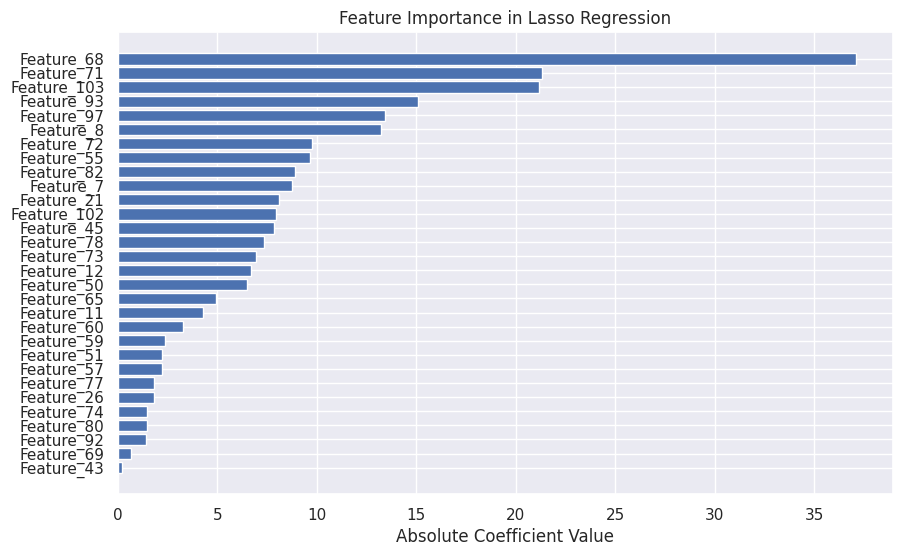

In [40]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from mglearn.datasets import load_extended_boston

# Load dataset
X, y = load_extended_boston()

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Lasso Regression
lasso = linear_model.Lasso(alpha=0.01).fit(X_train, y_train)

# Model performance
print("Training R² score: {:.4f}".format(lasso.score(X_train, y_train)))
print("Test R² score: {:.4f}".format(lasso.score(X_test, y_test)))
print("Number of features used:", np.sum(lasso.coef_ != 0))

# Get feature names (since extended_boston has unnamed features)
# Create synthetic feature names (since original dataset doesn't provide them)
feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_
})

# Sort by absolute coefficient value
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Get non-zero features
important_features = feature_importance[feature_importance['Coefficient'] != 0]

# Display results
print("\nMost Important Features (Non-Zero Coefficients):")
print(important_features)

print("\nTop Predictors (sorted by importance):")
print(important_features['Feature'].tolist())

# Optional: Visualize coefficients
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(important_features['Feature'], important_features['Abs_Coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance in Lasso Regression')
plt.gca().invert_yaxis()  # Most important at top
plt.show()

In [ ]:
# setting alpha = 0.01
lasso2 = linear_model.Lasso(alpha=0.01, max_iter = 100000).fit(X_train, y_train)
print("Training set score under Lasso regression: {:.2f}".format(lasso2.score(X_train,y_train)))
print("Test set score under Lasso regression: {:.2f}".format(lasso2.score(X_test,y_test)))
print("Number of features used under Lasso regression:", np.sum(lasso2.coef_ !=0))

Training set score under Lasso regression: 0.88
Test set score under Lasso regression: 0.82
Number of features used under Lasso regression: 30


We obtain a similar performance to that of Ridge regression by only using 33 features - a much simpler model without any performance sacrification. This is the beauty and power of Lasso regression -- feature selection + preventing overfitting through regularization!!!

We should again note that the optimal value of the model complexity parameter should be chosen through cross-validation.